# 08 - Reserved Capacity Sensitivity

This notebook asks whether `Q`, the number of Class-1-reserved slots per day, is the main control parameter for strict reservation.

The `Q` sweep is repeated for equal class arrival rates: $\lambda_1=\lambda_2 \in \{20,25,35,50\}$ arrivals per day.

Policy in focus and reference:

- **Strict C1 reservation:** `Q` slots per day are reserved for Class 1. Class 1 searches appointment days chronologically, trying reserved capacity before general capacity within the same day. Class 2 can only use general capacity. Unused reserved slots stay empty.
- **Pooled FCFS reference:** no reserved slots. It appears only as a light horizontal baseline.

In this notebook, the main utilization plot uses `booked_slot_utilization`: booked appointment slots on service days divided by available slots. No-shows still count as booked slots; cancellations that free the slot before service do not.


## Setup

Use the same simple repo-root detection and imports as notebook 07.

In [1]:
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable


def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "simulation" / "engine.py").exists() and (
            candidate / "analysis" / "metrics.py"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook location.")


REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import aggregate_result_row, class_result_rows
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import PatientClassParams, SimulationConfig, ThresholdRule

plt.style.use("default")

## Base Scenario

The demand levels use equal class arrival rates: `lambda_1 = lambda_2` at 20, 25, 35, and 50 arrivals per day. The sweep changes the number of reserved Class 1 slots `Q` for each demand level.

In [2]:
BASE_SCENARIO = {
    "slots_per_day": 32,
    "reserved_slots_per_day": 10,
    "reserved_class_id": 1,
    "horizon_days": 14,
    "burn_in_days": 30,
    "measure_days": 365,
    "cooldown_days": 14,
    "seeds": list(range(5101, 5131)),
    "classes": {
        1: {
            "lambda_per_day": 25.0,
            "cancel_prob": 0.10,
            "value": 1.0,
            "balk_prob": {"threshold": 9, "low": 0.00, "high": 0.50},
            "no_show_prob": {"threshold": 6, "low": 0.00, "high": 0.30},
        },
        2: {
            "lambda_per_day": 25.0,
            "cancel_prob": 0.10,
            "value": 1.0,
            "balk_prob": {"threshold": 9, "low": 0.00, "high": 0.50},
            "no_show_prob": {"threshold": 6, "low": 0.00, "high": 0.30},
        },
    },
}

Q_VALUES = [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 32]
ARRIVAL_RATE_VALUES = [20, 25, 35, 50]
STRICT_RESERVATION_POLICY = "Strict C1 reservation"
POLICY_COLORS = {
    "Strict C1 reservation": "tab:blue",
    "Pooled FCFS": "0.45",
}
LOST_COMPONENTS = [
    "balked_rate",
    "canceled_rate",
    "no_show_rate",
    "no_offer_rate",
    "unresolved_booked_rate",
]

scenario_table = pd.DataFrame(
    {
        "value": pd.Series(
            {
                key: value
                for key, value in BASE_SCENARIO.items()
                if key not in {"classes", "seeds"}
            },
            dtype="object",
        )
    }
)
scenario_table.loc["num_seeds", "value"] = len(BASE_SCENARIO["seeds"])
scenario_table.loc["seed_range", "value"] = f"{BASE_SCENARIO['seeds'][0]}-{BASE_SCENARIO['seeds'][-1]}"
scenario_table.loc["q_values", "value"] = Q_VALUES
scenario_table.loc["arrival_rate_values", "value"] = ARRIVAL_RATE_VALUES

class_table = pd.DataFrame(
    [
        {
            "class_id": class_id,
            "lambda_per_day": params["lambda_per_day"],
            "cancel_prob": params["cancel_prob"],
            "balk_threshold": params["balk_prob"]["threshold"],
            "balk_low": params["balk_prob"]["low"],
            "balk_high": params["balk_prob"]["high"],
            "no_show_threshold": params["no_show_prob"]["threshold"],
            "no_show_low": params["no_show_prob"]["low"],
            "no_show_high": params["no_show_prob"]["high"],
        }
        for class_id, params in BASE_SCENARIO["classes"].items()
    ]
)

display(scenario_table)
display(class_table)

,value
slots_per_day,32
reserved_slots_per_day,10
reserved_class_id,1
horizon_days,14
burn_in_days,30
measure_days,365
cooldown_days,14
num_seeds,30
seed_range,5101-5130
q_values,"[0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 32]"


,class_id,lambda_per_day,cancel_prob,balk_threshold,balk_low,balk_high,no_show_threshold,no_show_low,no_show_high
0,1,25.0,0.1,9,0.0,0.5,6,0.0,0.3
1,2,25.0,0.1,9,0.0,0.5,6,0.0,0.3


## Small Helpers

The helpers below are intentionally narrow: build one simulation config, update `Q`, run the Q sweep, add outcome rates, and check accounting.

In [3]:
def build_config(scenario: dict, policy: str, seed: int | None) -> SimulationConfig:
    classes = {}
    for class_id, params in scenario["classes"].items():
        classes[class_id] = PatientClassParams(
            class_id=class_id,
            lambda_per_day=float(params["lambda_per_day"]),
            balk_prob=ThresholdRule(**params["balk_prob"]),
            cancel_prob=float(params["cancel_prob"]),
            no_show_prob=ThresholdRule(**params["no_show_prob"]),
            value=float(params.get("value", 1.0)),
        )

    reserved = policy != "Pooled FCFS"
    reserved_slots = int(scenario["reserved_slots_per_day"]) if reserved else 0

    return SimulationConfig(
        slots_per_day=int(scenario["slots_per_day"]),
        horizon_days=int(scenario["horizon_days"]),
        burn_in_days=int(scenario["burn_in_days"]),
        measure_days=int(scenario["measure_days"]),
        cooldown_days=int(scenario["cooldown_days"]),
        classes=classes,
        seed=seed,
        reserved_class_id=scenario["reserved_class_id"] if reserved_slots > 0 else None,
        reserved_slots_per_day=reserved_slots,
    )


def make_scenario(q: int, arrival_rate_per_class: float | None = None, base_scenario: dict = BASE_SCENARIO) -> dict:
    scenario = deepcopy(base_scenario)
    scenario["reserved_slots_per_day"] = int(q)
    if arrival_rate_per_class is not None:
        for params in scenario["classes"].values():
            params["lambda_per_day"] = float(arrival_rate_per_class)
    return scenario


def add_rates(aggregate_df: pd.DataFrame, class_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    aggregate_df = aggregate_df.copy()
    class_df = class_df.copy()

    arrivals = aggregate_df["total_arrivals"]
    aggregate_df["served_rate"] = aggregate_df["total_served"].div(arrivals).where(arrivals != 0, 0.0)
    aggregate_df["balked_rate"] = aggregate_df["total_balked"].div(arrivals).where(arrivals != 0, 0.0)
    aggregate_df["no_offer_rate"] = aggregate_df["total_no_offer"].div(arrivals).where(arrivals != 0, 0.0)
    aggregate_df["canceled_rate"] = aggregate_df["total_canceled"].div(arrivals).where(arrivals != 0, 0.0)
    aggregate_df["no_show_rate"] = aggregate_df["total_no_show"].div(arrivals).where(arrivals != 0, 0.0)
    aggregate_df["unresolved_booked_rate"] = aggregate_df["total_unresolved_booked"].div(arrivals).where(arrivals != 0, 0.0)
    aggregate_df["lost_components_sum"] = aggregate_df[LOST_COMPONENTS].sum(axis=1)
    aggregate_df["lost_rate"] = 1.0 - aggregate_df["served_rate"]

    class_df["unresolved_booked"] = class_df["booked"] - class_df["canceled"] - class_df["no_show"] - class_df["served"]
    class_arrivals = class_df["arrivals"]
    class_df["served_rate"] = class_df["percent_serviced"]
    class_df["balked_rate"] = class_df["balked"].div(class_arrivals).where(class_arrivals != 0, 0.0)
    class_df["no_offer_rate"] = class_df["no_offer"].div(class_arrivals).where(class_arrivals != 0, 0.0)
    class_df["canceled_rate"] = class_df["canceled"].div(class_arrivals).where(class_arrivals != 0, 0.0)
    class_df["no_show_rate"] = class_df["no_show"].div(class_arrivals).where(class_arrivals != 0, 0.0)
    class_df["unresolved_booked_rate"] = class_df["unresolved_booked"].div(class_arrivals).where(class_arrivals != 0, 0.0)
    class_df["lost_components_sum"] = class_df[LOST_COMPONENTS].sum(axis=1)
    class_df["lost_rate"] = 1.0 - class_df["served_rate"]

    return aggregate_df, class_df


def validate_accounting(aggregate_df: pd.DataFrame, class_df: pd.DataFrame, tol: float = 1e-9) -> None:
    aggregate_partition = (
        aggregate_df["total_served"]
        + aggregate_df["total_balked"]
        + aggregate_df["total_no_offer"]
        + aggregate_df["total_canceled"]
        + aggregate_df["total_no_show"]
        + aggregate_df["total_unresolved_booked"]
    )
    if (aggregate_partition - aggregate_df["total_arrivals"]).abs().max() > tol:
        raise AssertionError("Aggregate outcomes do not partition arrivals.")
    if (aggregate_df["total_unresolved_booked"] < -tol).any():
        raise AssertionError("Aggregate unresolved_booked is negative.")
    if (aggregate_df["lost_rate"] - (1.0 - aggregate_df["served_rate"])).abs().max() > tol:
        raise AssertionError("Aggregate lost_rate is not 1 - served_rate.")
    if (aggregate_df["lost_components_sum"] - aggregate_df["lost_rate"]).abs().max() > tol:
        raise AssertionError("Aggregate lost components do not sum to lost_rate.")

    class_partition = (
        class_df["served"]
        + class_df["balked"]
        + class_df["no_offer"]
        + class_df["canceled"]
        + class_df["no_show"]
        + class_df["unresolved_booked"]
    )
    if (class_partition - class_df["arrivals"]).abs().max() > tol:
        raise AssertionError("Class outcomes do not partition arrivals.")
    if (class_df["unresolved_booked"] < -tol).any():
        raise AssertionError("Class unresolved_booked is negative.")
    if (class_df["lost_rate"] - (1.0 - class_df["served_rate"])).abs().max() > tol:
        raise AssertionError("Class lost_rate is not 1 - served_rate.")
    if (class_df["lost_components_sum"] - class_df["lost_rate"]).abs().max() > tol:
        raise AssertionError("Class lost components do not sum to lost_rate.")


def run_q_sweep(q_values: list[int], arrival_rate_values: list[float]) -> tuple[pd.DataFrame, pd.DataFrame]:
    aggregate_rows = []
    class_rows = []

    for arrival_rate in tqdm(arrival_rate_values, desc="arrival rates"):
        for q in tqdm(q_values, desc=f"Q values, lambda={arrival_rate:g}", leave=False):
            scenario = make_scenario(q, arrival_rate_per_class=arrival_rate)
            fixed_metadata = {
                "arrival_rate_per_class": float(arrival_rate),
                "lambda_1": scenario["classes"][1]["lambda_per_day"],
                "lambda_2": scenario["classes"][2]["lambda_per_day"],
            }
            for seed in scenario["seeds"]:
                config = build_config(scenario, STRICT_RESERVATION_POLICY, seed=int(seed))
                result = ClinicAppointmentSimulation(config).run()
                fixed_values = {**fixed_metadata, "policy": STRICT_RESERVATION_POLICY, "seed": int(seed), "Q": int(q)}
                aggregate_rows.append(aggregate_result_row(result, fixed_values))
                class_rows.extend(class_result_rows(result, fixed_values))

    aggregate_df = pd.DataFrame(aggregate_rows)
    class_df = pd.DataFrame(class_rows)
    aggregate_df, class_df = add_rates(aggregate_df, class_df)
    validate_accounting(aggregate_df, class_df)
    return aggregate_df, class_df

## Q Sweep

Run strict reservation for each `Q` and each equal class arrival rate. Pooled FCFS is run once per arrival rate at `Q = 0` and used only as a reference.


In [4]:
q_aggregate_df, q_class_df = run_q_sweep(Q_VALUES, ARRIVAL_RATE_VALUES)

fcfs_aggregate_rows = []
fcfs_class_rows = []
for arrival_rate in tqdm(ARRIVAL_RATE_VALUES, desc="Pooled FCFS reference"):
    fcfs_scenario = make_scenario(0, arrival_rate_per_class=arrival_rate)
    fixed_metadata = {
        "arrival_rate_per_class": float(arrival_rate),
        "lambda_1": fcfs_scenario["classes"][1]["lambda_per_day"],
        "lambda_2": fcfs_scenario["classes"][2]["lambda_per_day"],
    }
    for seed in fcfs_scenario["seeds"]:
        config = build_config(fcfs_scenario, "Pooled FCFS", seed=int(seed))
        result = ClinicAppointmentSimulation(config).run()
        fixed_values = {**fixed_metadata, "policy": "Pooled FCFS", "seed": int(seed), "Q": 0}
        fcfs_aggregate_rows.append(aggregate_result_row(result, fixed_values))
        fcfs_class_rows.extend(class_result_rows(result, fixed_values))

fcfs_aggregate_df = pd.DataFrame(fcfs_aggregate_rows)
fcfs_class_df = pd.DataFrame(fcfs_class_rows)
fcfs_aggregate_df, fcfs_class_df = add_rates(fcfs_aggregate_df, fcfs_class_df)
validate_accounting(fcfs_aggregate_df, fcfs_class_df)

print(f"Strict-reservation runs: {len(q_aggregate_df):,}")
print(f"FCFS reference runs: {len(fcfs_aggregate_df):,}")

arrival rates:   0%|          | 0/4 [00:00<?, ?it/s]

Q values, lambda=20:   0%|          | 0/12 [00:00<?, ?it/s]

Q values, lambda=25:   0%|          | 0/12 [00:00<?, ?it/s]

Q values, lambda=35:   0%|          | 0/12 [00:00<?, ?it/s]

Q values, lambda=50:   0%|          | 0/12 [00:00<?, ?it/s]

Pooled FCFS reference:   0%|          | 0/4 [00:00<?, ?it/s]

Strict-reservation runs: 1,440
FCFS reference runs: 120


## Summary Tables

In [5]:
aggregate_columns = [
    "served_rate",
    "average_utilization",
    "booked_slot_utilization",
    "mean_offered_booking_delay",
    "lost_rate",
    "balked_rate",
    "no_offer_rate",
    "canceled_rate",
    "no_show_rate",
    "unresolved_booked_rate",
]
class_columns = [
    "served_rate",
    "mean_offered_booking_delay",
    "lost_rate",
    "balked_rate",
    "no_offer_rate",
    "canceled_rate",
    "no_show_rate",
    "unresolved_booked_rate",
]

aggregate_means = (
    q_aggregate_df.groupby(["arrival_rate_per_class", "Q", "policy"])[aggregate_columns]
    .mean()
    .round(4)
)
class_means = (
    q_class_df.groupby(["arrival_rate_per_class", "Q", "policy", "class_id"])[class_columns]
    .mean()
    .round(4)
)
fcfs_aggregate_reference = (
    fcfs_aggregate_df.groupby(["arrival_rate_per_class", "policy"])[aggregate_columns]
    .mean()
    .round(4)
)
fcfs_class_reference = (
    fcfs_class_df.groupby(["arrival_rate_per_class", "policy", "class_id"])[class_columns]
    .mean()
    .round(4)
)

display(aggregate_means)
display(class_means)
print("Pooled FCFS reference")
display(fcfs_aggregate_reference)
display(fcfs_class_reference)

served_rate  \
arrival_rate_per_class Q  policy                               
20.0                   0  Strict C1 reservation       0.7991   
                       2  Strict C1 reservation       0.7991   
                       4  Strict C1 reservation       0.7991   
                       6  Strict C1 reservation       0.7991   
                       8  Strict C1 reservation       0.7991   
                       10 Strict C1 reservation       0.7991   
                       12 Strict C1 reservation       0.7991   
                       16 Strict C1 reservation       0.7989   
                       20 Strict C1 reservation       0.7515   
                       24 Strict C1 reservation       0.6667   
                       28 Strict C1 reservation       0.5831   
                       32 Strict C1 reservation       0.4995   
25.0                   0  Strict C1 reservation       0.5801   
                       2  Strict C1 reservation       0.5801   
                       4  Strict C1 reservation       0.5801   
                       6  Strict C1 reservation       0.5801   
                       8  Strict C1 reservation       0.5801   
                       10 Strict C1 reservation       0.5801   
                       12 Strict C1 reservation       0.5801   
                       16 Strict C1 reservation       0.5869   
                       20 Strict C1 reservation       0.6031   
                       24 Strict C1 reservation       0.6136   
                       28 Strict C1 reservation       0.5670   
                       32 Strict C1 reservation       0.5001   
35.0                   0  Strict C1 reservation       0.3847   
                       2  Strict C1 reservation       0.3847   
                       4  Strict C1 reservation       0.3847   
                       6  Strict C1 reservation       0.3850   
                       8  Strict C1 reservation       0.3847   
                       10 Strict C1 reservation       0.3847   
                       12 Strict C1 reservation       0.3831   
                       16 Strict C1 reservation       0.3849   
                       20 Strict C1 reservation       0.3847   
                       24 Strict C1 reservation       0.4353   
                       28 Strict C1 reservation       0.4485   
                       32 Strict C1 reservation       0.4572   
50.0                   0  Strict C1 reservation       0.2693   
                       2  Strict C1 reservation       0.2686   
                       4  Strict C1 reservation       0.2684   
                       6  Strict C1 reservation       0.2687   
                       8  Strict C1 reservation       0.2689   
                       10 Strict C1 reservation       0.2689   
                       12 Strict C1 reservation       0.2690   
                       16 Strict C1 reservation       0.2689   
                       20 Strict C1 reservation       0.2687   
                       24 Strict C1 reservation       0.2688   
                       28 Strict C1 reservation       0.2694   
                       32 Strict C1 reservation       0.2911   

                                                 average_utilization  \
arrival_rate_per_class Q  policy                                       
20.0                   0  Strict C1 reservation               1.0000   
                       2  Strict C1 reservation               1.0000   
                       4  Strict C1 reservation               1.0000   
                       6  Strict C1 reservation               1.0000   
                       8  Strict C1 reservation               1.0000   
                       10 Strict C1 reservation               1.0000   
                       12 Strict C1 reservation               1.0000   
                       16 Strict C1 reservation               1.0000   
                       20 Strict C1 reservation               0.9401   
                       24 Strict C1 reservation         

served_rate  \
arrival_rate_per_class Q  policy                class_id                
20.0                   0  Strict C1 reservation 1              0.7997   
                                                2              0.7985   
                       2  Strict C1 reservation 1              0.7999   
                                                2              0.7982   
                       4  Strict C1 reservation 1              0.8003   
...                                                               ...   
50.0                   24 Strict C1 reservation 2              0.1289   
                       28 Strict C1 reservation 1              0.4733   
                                                2              0.0656   
                       32 Strict C1 reservation 1              0.5828   
                                                2              0.0000   

                                                          mean_offered_booking_delay  \
arrival_rate_per_class Q  policy                class_id                               
20.0                   0  Strict C1 reservation 1                             3.1794   
                                                2                             3.1760   
                       2  Strict C1 reservation 1                             3.1767   
                                                2                             3.1787   
                       4  Strict C1 reservation 1                             3.1729   
...                                                                              ...   
50.0                   24 Strict C1 reservation 2                            10.6935   
                       28 Strict C1 reservation 1                             6.7528   
                                                2                            10.6748   
                       32 Strict C1 reservation 1                             5.4423   
                                                2                             0.0000   

                                                          lost_rate  \
arrival_rate_per_class Q  policy                class_id              
20.0                   0  Strict C1 reservation 1            0.2003   
                                                2            0.2015   
                       2  Strict C1 reservation 1            0.2001   
                                                2            0.2018   
                       4  Strict C1 reservation 1            0.1997   
...                                                             ...   
50.0                   24 Strict C1 reservation 2            0.8711   
                       28 Strict C1 reservation 1            0.5267   
                                                2            0.9344   
                       32 Strict C1 reservation 1            0.4172   
                                                2            1.0000   

                                                          balked_rate  \
arrival_rate_per_class Q  policy                class_id                
20.0                   0  Strict C1 reservation 1              0.0000   
                                                2              0.0000   
                       2  Strict C1 reservation 1              0.0000   
                                                2              0.0000   
                       4  Strict C1 reservation 1              0.0000   
...                                                               ...   
50.0                   24 Strict C1 reservation 2              0.2069   
                       28 Strict C1 reservation 1              0.0148   
                                                2              0.1047   
                       32 Strict C1 reservation 1              0.0000   
                                                2              0.0000   

                                                          no_offer_rate  \
arrival_rate_p

Pooled FCFS reference


,,served_rate,average_utilization,booked_slot_utilization,mean_offered_booking_delay,lost_rate,balked_rate,no_offer_rate,canceled_rate,no_show_rate,unresolved_booked_rate
arrival_rate_per_class,policy,,,,,,,,,,
20.0,Pooled FCFS,0.7991,1.0000,1.0,3.1777,0.2009,0.0000,0.0,0.2009,0.0000,0.0
25.0,Pooled FCFS,0.5801,0.9076,1.0,5.4615,0.4199,0.0000,0.0,0.3603,0.0596,0.0
35.0,Pooled FCFS,0.3847,0.8405,1.0,7.6697,0.6153,0.1601,0.0,0.3823,0.0729,0.0
50.0,Pooled FCFS,0.2693,0.8405,1.0,9.3037,0.7307,0.3558,0.0,0.3237,0.0511,0.0


served_rate  \
arrival_rate_per_class policy      class_id                
20.0                   Pooled FCFS 1              0.7997   
                                   2              0.7985   
25.0                   Pooled FCFS 1              0.5812   
                                   2              0.5791   
35.0                   Pooled FCFS 1              0.3839   
                                   2              0.3855   
50.0                   Pooled FCFS 1              0.2696   
                                   2              0.2690   

                                             mean_offered_booking_delay  \
arrival_rate_per_class policy      class_id                               
20.0                   Pooled FCFS 1                             3.1794   
                                   2                             3.1760   
25.0                   Pooled FCFS 1                             5.4596   
                                   2                             5.4635   
35.0                   Pooled FCFS 1                             7.6763   
                                   2                             7.6631   
50.0                   Pooled FCFS 1                             9.2996   
                                   2                             9.3079   

                                             lost_rate  balked_rate  \
arrival_rate_per_class policy      class_id                           
20.0                   Pooled FCFS 1            0.2003       0.0000   
                                   2            0.2015       0.0000   
25.0                   Pooled FCFS 1            0.4188       0.0000   
                                   2            0.4209       0.0000   
35.0                   Pooled FCFS 1            0.6161       0.1601   
                                   2            0.6145       0.1601   
50.0                   Pooled FCFS 1            0.7304       0.3553   
                                   2            0.7310       0.3563   

                                             no_offer_rate  canceled_rate  \
arrival_rate_per_class policy      class_id                                 
20.0                   Pooled FCFS 1                   0.0         0.2003   
                                   2                   0.0         0.2015   
25.0                   Pooled FCFS 1                   0.0         0.3597   
                                   2                   0.0         0.3609   
35.0                   Pooled FCFS 1                   0.0         0.3825   
                                   2                   0.0         0.3822   
50.0                   Pooled FCFS 1                   0.0         0.3236   
                                   2                   0.0         0.3239   

                                             no_show_rate  \
arrival_rate_per_class policy      class_id                 
20.0                   Pooled FCFS 1               0.0000   
                                   2               0.0000   
25.0                   Pooled FCFS 1               0.0591   
                                   2               0.0601   
35.0                   Pooled FCFS 1               0.0735   
                                   2               0.0723   
50.0                   Pooled FCFS 1               0.0514   
                                   2               0.0508   

                                             unresolved_booked_rate  
arrival_rate_per_class policy      class_id                          
20.0                   Pooled FCFS 1                            0.0  
                                   2                            0.0  
25.0                   Pooled FCFS 1                            0.0  
                                   2                            0.0  
35.0                   Pooled FCFS 1                            0.0  
                                   2                            0.0  
50.0                   Pooled FCFS 1    

## Main Plots

The active plots below compare Class 1 and Class 2 values directly. When FCFS is shown, dashed lines are the FCFS references for the same class and arrival rate.


In [6]:
reserved_slot_label = "Reserved Class 1 slots per day, Q"
arrival_rate_values = sorted(q_aggregate_df["arrival_rate_per_class"].unique())
arrival_rate_colors = {
    arrival_rate: color
    for arrival_rate, color in zip(
        arrival_rate_values,
        plt.cm.viridis(np.linspace(0.15, 0.85, len(arrival_rate_values))),
    )
}

aggregate_plot = (
    q_aggregate_df.groupby(["arrival_rate_per_class", "Q", "policy"])[aggregate_columns]
    .mean()
    .reset_index()
)

class_plot = (
    q_class_df.groupby(["arrival_rate_per_class", "Q", "policy", "class_id"])[class_columns]
    .mean()
    .reset_index()
)

fcfs_aggregate_plot = fcfs_aggregate_df.groupby("arrival_rate_per_class")[aggregate_columns].mean()
fcfs_class_plot = fcfs_class_df.groupby(["arrival_rate_per_class", "class_id"])[class_columns].mean()


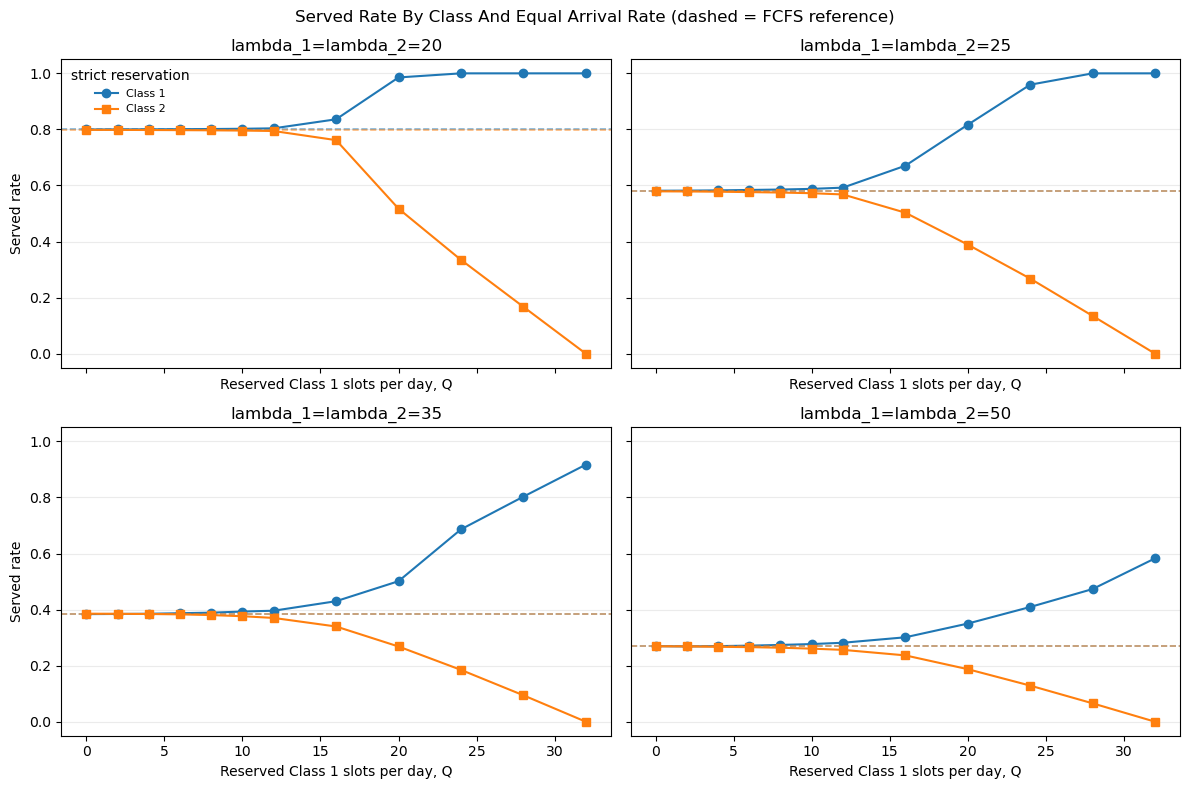

In [7]:
class_colors = {1: "tab:blue", 2: "tab:orange"}
class_markers = {1: "o", 2: "s"}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

policy = STRICT_RESERVATION_POLICY
for ax, arrival_rate in zip(axes, arrival_rate_values):
    for class_id in [1, 2]:
        subset = class_plot[
            (class_plot["policy"] == policy)
            & (class_plot["class_id"] == class_id)
            & (class_plot["arrival_rate_per_class"] == arrival_rate)
        ].sort_values("Q")

        ax.plot(
            subset["Q"],
            subset["served_rate"],
            marker=class_markers[class_id],
            color=class_colors[class_id],
            label=f"Class {class_id}",
        )
        ax.axhline(
            fcfs_class_plot.loc[(arrival_rate, class_id), "served_rate"],
            color=class_colors[class_id],
            linestyle="--",
            linewidth=1.2,
            alpha=0.55,
        )

    ax.set_title(f"lambda_1=lambda_2={arrival_rate:g}")
    ax.set_xlabel(reserved_slot_label)
    ax.grid(axis="y", alpha=0.25)

for ax in axes[::2]:
    ax.set_ylabel("Served rate")
axes[0].legend(title="strict reservation", fontsize=8, frameon=False)
fig.suptitle("Served Rate By Class And Equal Arrival Rate (dashed = FCFS reference)")
fig.tight_layout()


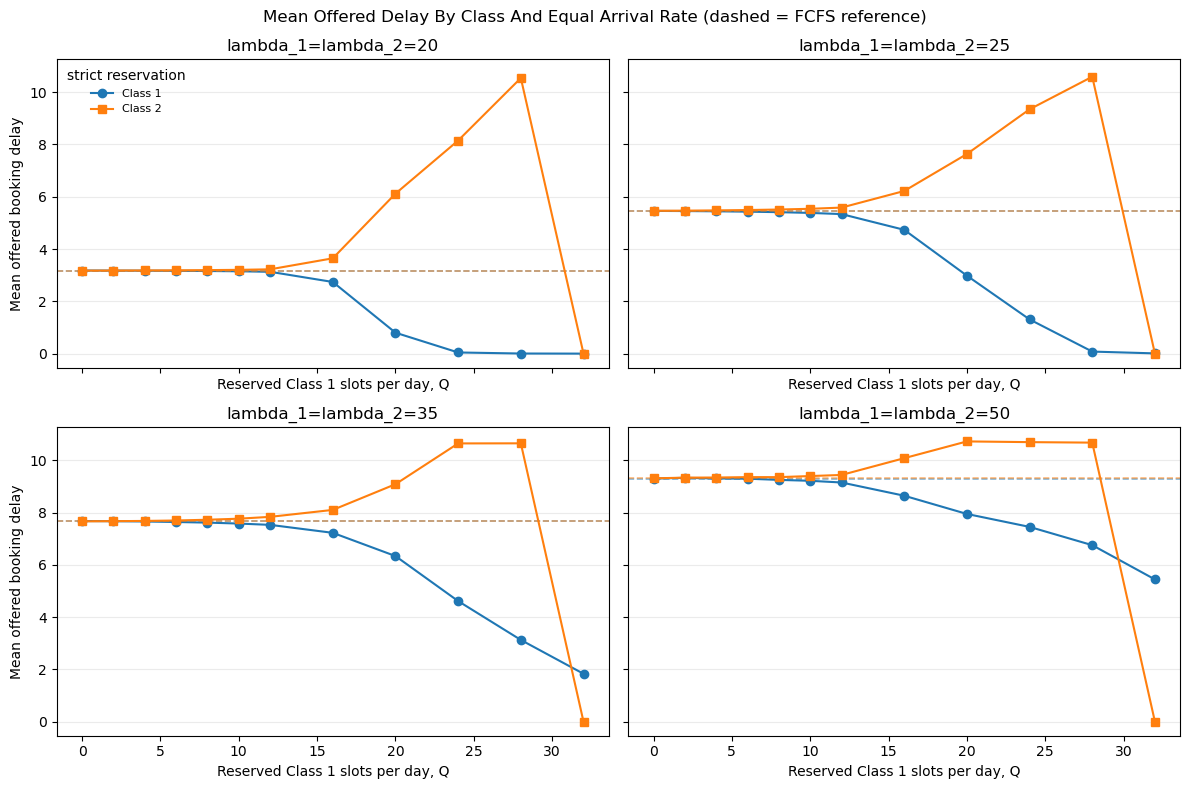

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

policy = STRICT_RESERVATION_POLICY
for ax, arrival_rate in zip(axes, arrival_rate_values):
    for class_id in [1, 2]:
        subset = class_plot[
            (class_plot["policy"] == policy)
            & (class_plot["class_id"] == class_id)
            & (class_plot["arrival_rate_per_class"] == arrival_rate)
        ].sort_values("Q")

        ax.plot(
            subset["Q"],
            subset["mean_offered_booking_delay"],
            marker=class_markers[class_id],
            color=class_colors[class_id],
            label=f"Class {class_id}",
        )
        ax.axhline(
            fcfs_class_plot.loc[(arrival_rate, class_id), "mean_offered_booking_delay"],
            color=class_colors[class_id],
            linestyle="--",
            linewidth=1.2,
            alpha=0.55,
        )

    ax.set_title(f"lambda_1=lambda_2={arrival_rate:g}")
    ax.set_xlabel(reserved_slot_label)
    ax.grid(axis="y", alpha=0.25)

for ax in axes[::2]:
    ax.set_ylabel("Mean offered booking delay")
axes[0].legend(title="strict reservation", fontsize=8, frameon=False)
fig.suptitle("Mean Offered Delay By Class And Equal Arrival Rate (dashed = FCFS reference)")
fig.tight_layout()


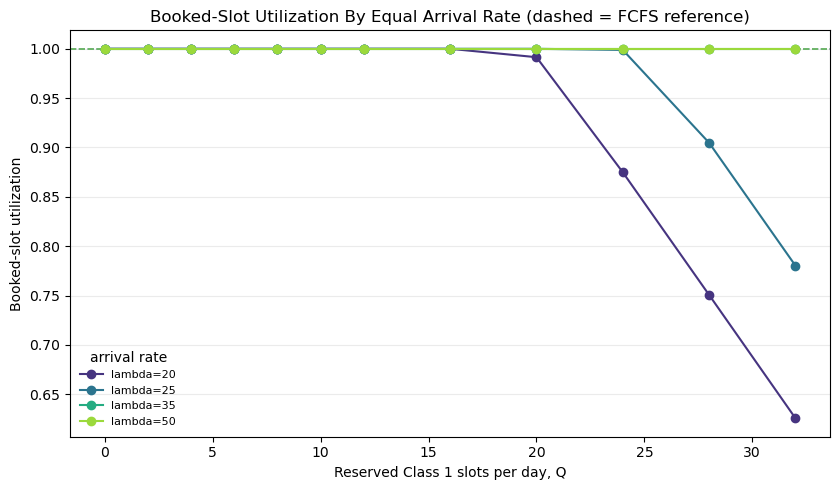

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5))

policy = STRICT_RESERVATION_POLICY
for arrival_rate in arrival_rate_values:
    subset = aggregate_plot[
        (aggregate_plot["policy"] == policy)
        & (aggregate_plot["arrival_rate_per_class"] == arrival_rate)
    ].sort_values("Q")

    ax.plot(
        subset["Q"],
        subset["booked_slot_utilization"],
        marker="o",
        color=arrival_rate_colors[arrival_rate],
        label=f"lambda={arrival_rate:g}",
    )
    ax.axhline(
        fcfs_aggregate_plot.loc[arrival_rate, "booked_slot_utilization"],
        color=arrival_rate_colors[arrival_rate],
        linestyle="--",
        linewidth=1.2,
        alpha=0.55,
    )

ax.set_title("Booked-Slot Utilization By Equal Arrival Rate (dashed = FCFS reference)")
ax.set_xlabel(reserved_slot_label)
ax.set_ylabel("Booked-slot utilization")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="arrival rate", fontsize=8, frameon=False)

fig.tight_layout()

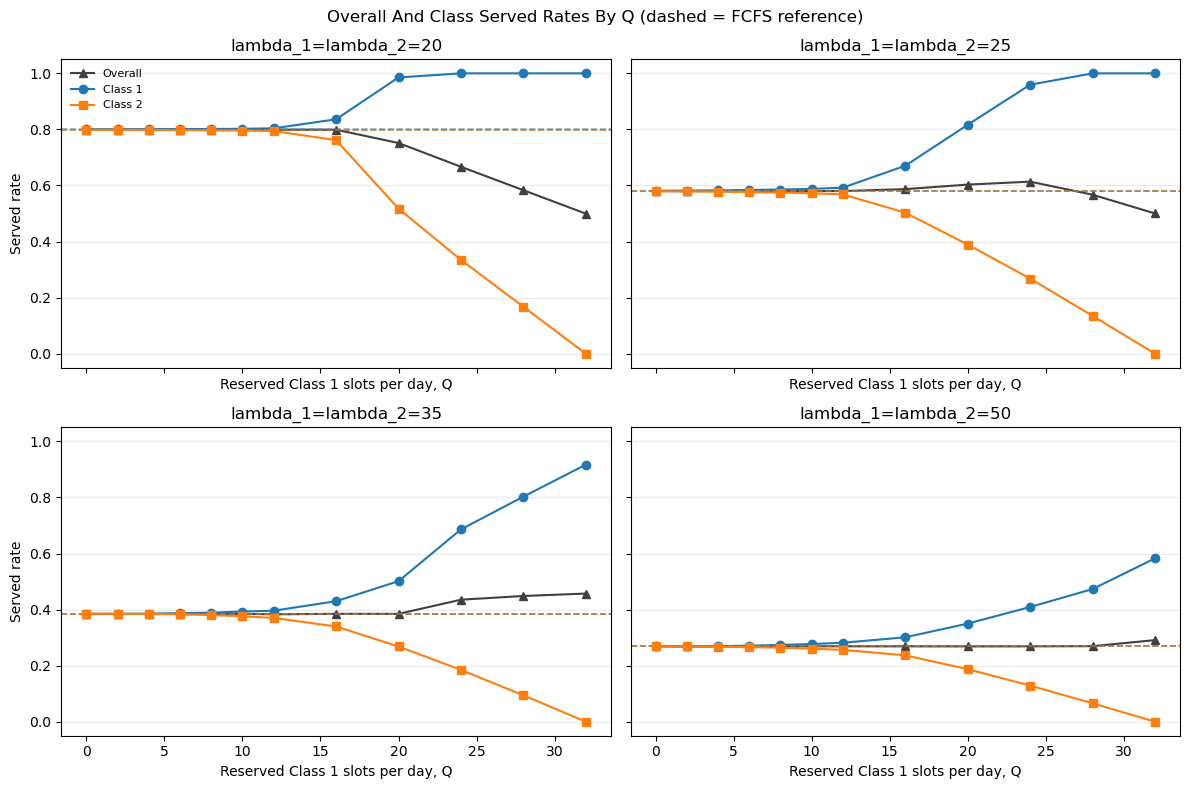

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

policy = STRICT_RESERVATION_POLICY
for ax, arrival_rate in zip(axes, arrival_rate_values):
    aggregate_subset = aggregate_plot[
        (aggregate_plot["policy"] == policy)
        & (aggregate_plot["arrival_rate_per_class"] == arrival_rate)
    ].sort_values("Q")
    ax.plot(
        aggregate_subset["Q"],
        aggregate_subset["served_rate"],
        marker="^",
        color="0.25",
        label="Overall",
    )
    ax.axhline(
        fcfs_aggregate_plot.loc[arrival_rate, "served_rate"],
        color="0.25",
        linestyle="--",
        linewidth=1.2,
        alpha=0.55,
    )

    for class_id in [1, 2]:
        class_subset = class_plot[
            (class_plot["policy"] == policy)
            & (class_plot["class_id"] == class_id)
            & (class_plot["arrival_rate_per_class"] == arrival_rate)
        ].sort_values("Q")
        ax.plot(
            class_subset["Q"],
            class_subset["served_rate"],
            marker=class_markers[class_id],
            color=class_colors[class_id],
            label=f"Class {class_id}",
        )
        ax.axhline(
            fcfs_class_plot.loc[(arrival_rate, class_id), "served_rate"],
            color=class_colors[class_id],
            linestyle="--",
            linewidth=1.2,
            alpha=0.55,
        )

    ax.set_title(f"lambda_1=lambda_2={arrival_rate:g}")
    ax.set_xlabel(reserved_slot_label)
    ax.grid(axis="y", alpha=0.25)

for ax in axes[::2]:
    ax.set_ylabel("Served rate")
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("Overall And Class Served Rates By Q (dashed = FCFS reference)")
fig.tight_layout()


## Short Interpretation Placeholders

- Low Q:
- Intermediate Q:
- High Q:
- Strict reservation compared with FCFS across arrival rates:


## Accounting Checks

The sweep and FCFS reference both call `validate_accounting` immediately after running. This final cell repeats the checks explicitly.

In [11]:
for arrival_rate in ARRIVAL_RATE_VALUES:
    for q in Q_VALUES:
        validate_accounting(
            q_aggregate_df[
                (q_aggregate_df["arrival_rate_per_class"] == arrival_rate)
                & (q_aggregate_df["Q"] == q)
            ],
            q_class_df[
                (q_class_df["arrival_rate_per_class"] == arrival_rate)
                & (q_class_df["Q"] == q)
            ],
        )
    validate_accounting(
        fcfs_aggregate_df[fcfs_aggregate_df["arrival_rate_per_class"] == arrival_rate],
        fcfs_class_df[fcfs_class_df["arrival_rate_per_class"] == arrival_rate],
    )

print("Accounting checks passed for every Q, arrival rate, and FCFS reference.")

Accounting checks passed for every Q, arrival rate, and FCFS reference.


## Final Note

This notebook feeds the Q-sensitivity figures in the short findings document. It compares the strict-reservation Q sweep across equal class arrival rates, but it is not a full behavioral sensitivity analysis.